In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [27]:
df = pd.read_csv("creditcard.csv")

In [28]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [29]:
df.isnull().sum

<bound method DataFrame.sum of          Time     V1     V2     V3     V4     V5     V6     V7     V8     V9  \
0       False  False  False  False  False  False  False  False  False  False   
1       False  False  False  False  False  False  False  False  False  False   
2       False  False  False  False  False  False  False  False  False  False   
3       False  False  False  False  False  False  False  False  False  False   
4       False  False  False  False  False  False  False  False  False  False   
...       ...    ...    ...    ...    ...    ...    ...    ...    ...    ...   
284802  False  False  False  False  False  False  False  False  False  False   
284803  False  False  False  False  False  False  False  False  False  False   
284804  False  False  False  False  False  False  False  False  False  False   
284805  False  False  False  False  False  False  False  False  False  False   
284806  False  False  False  False  False  False  False  False  False  False   

        

In [30]:
df.dropna()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [31]:
df.shape

(284807, 31)

In [32]:
print(df.info())

print(df.describe())

print(df['Class'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

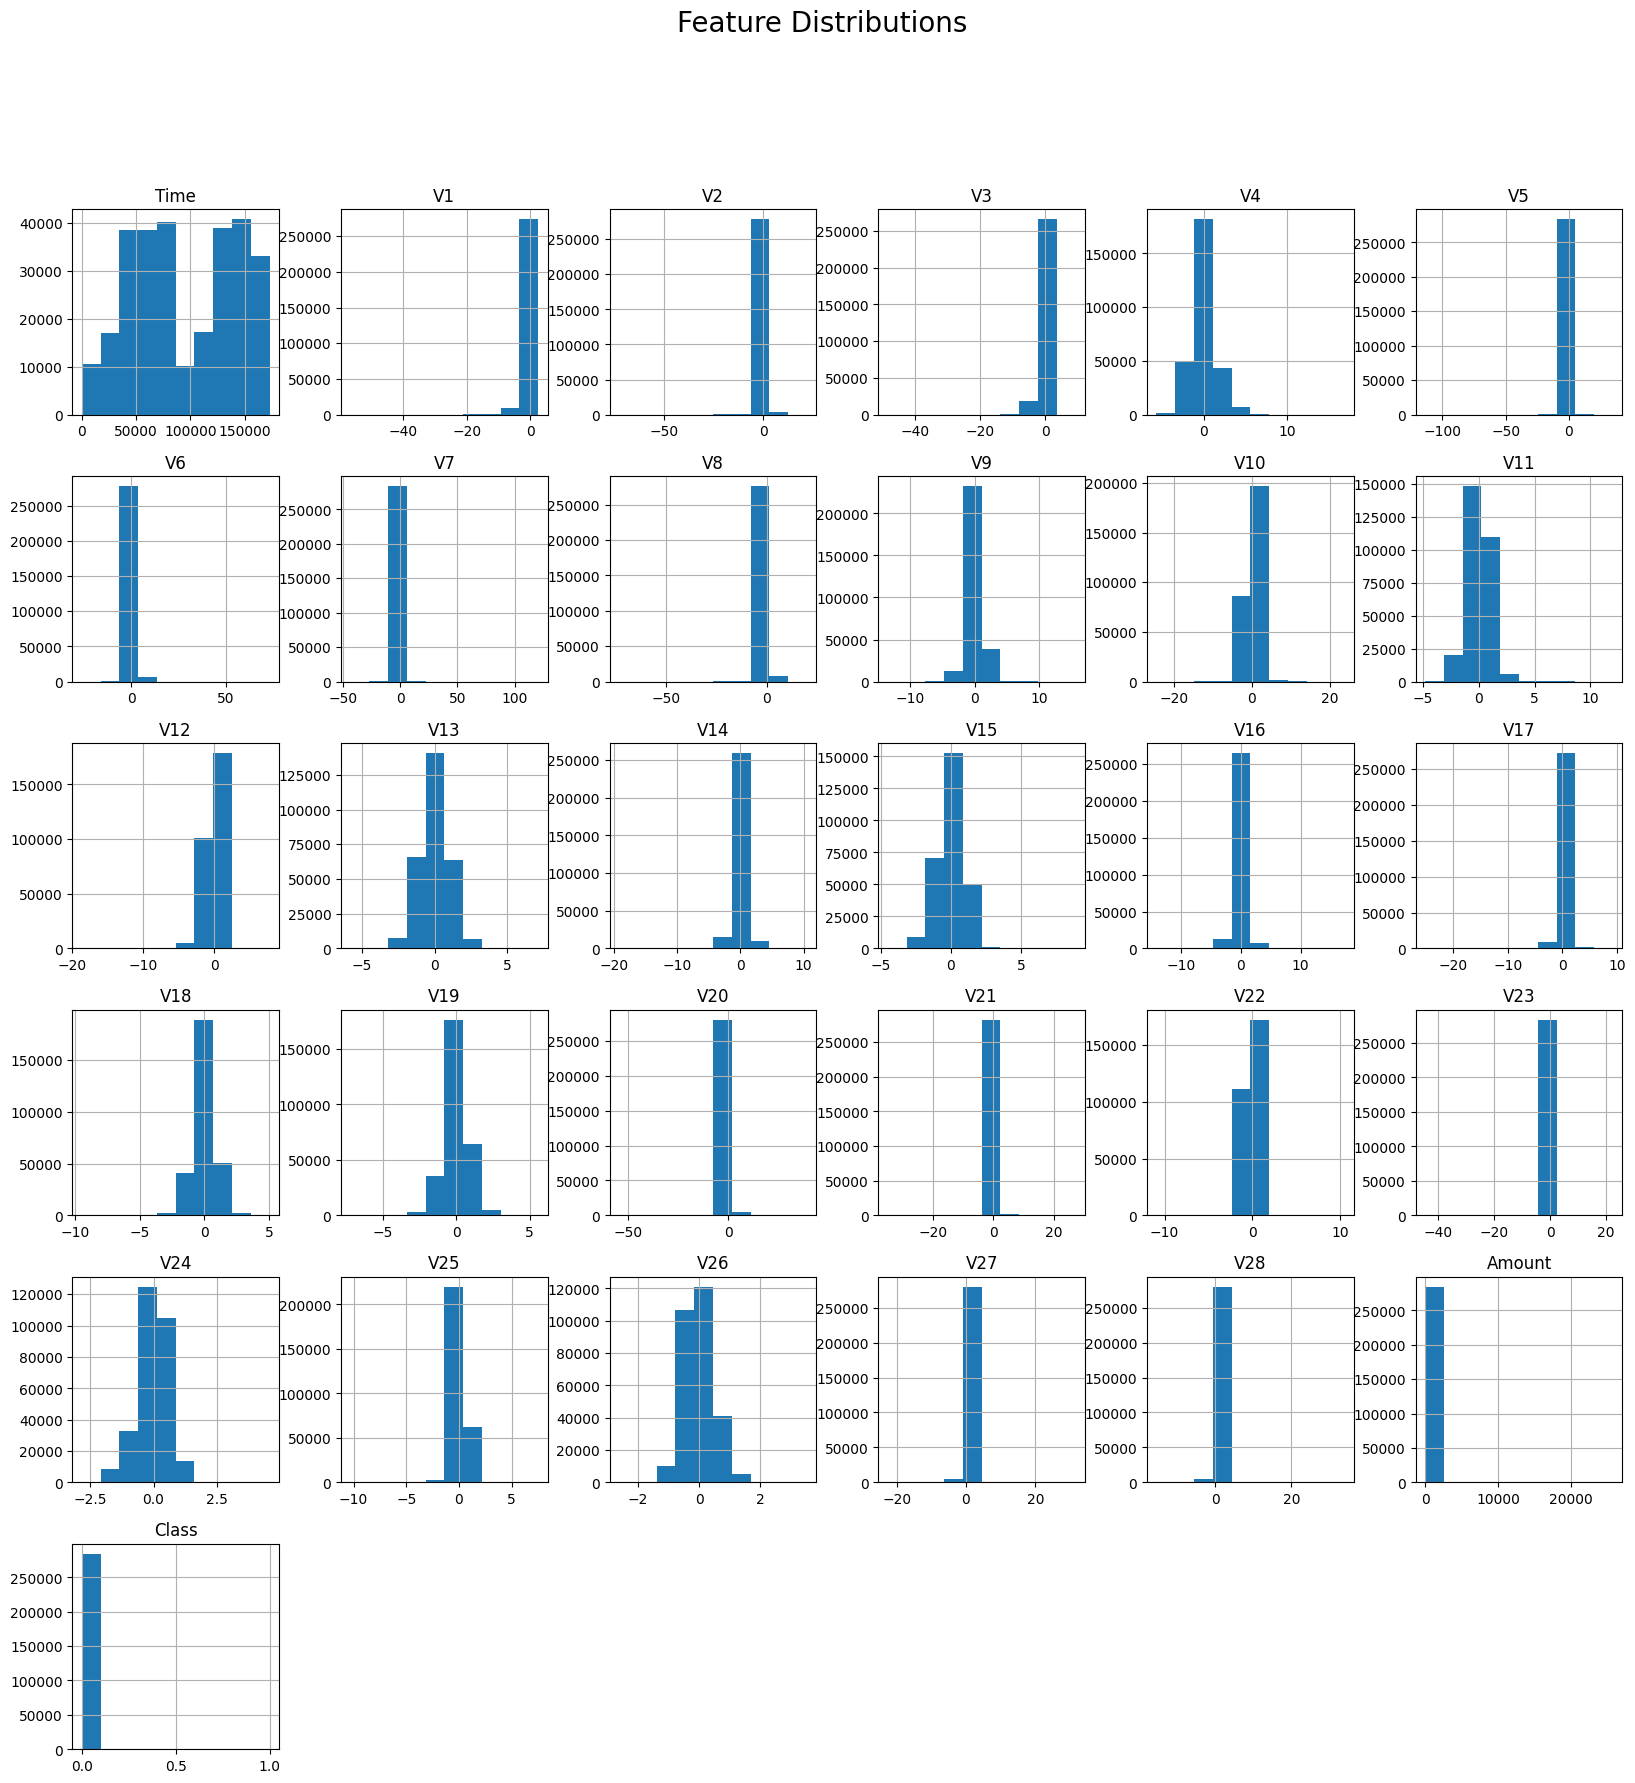

In [33]:
df.hist(figsize=(20,20))
plt.suptitle("Feature Distributions", fontsize=20)
plt.show()

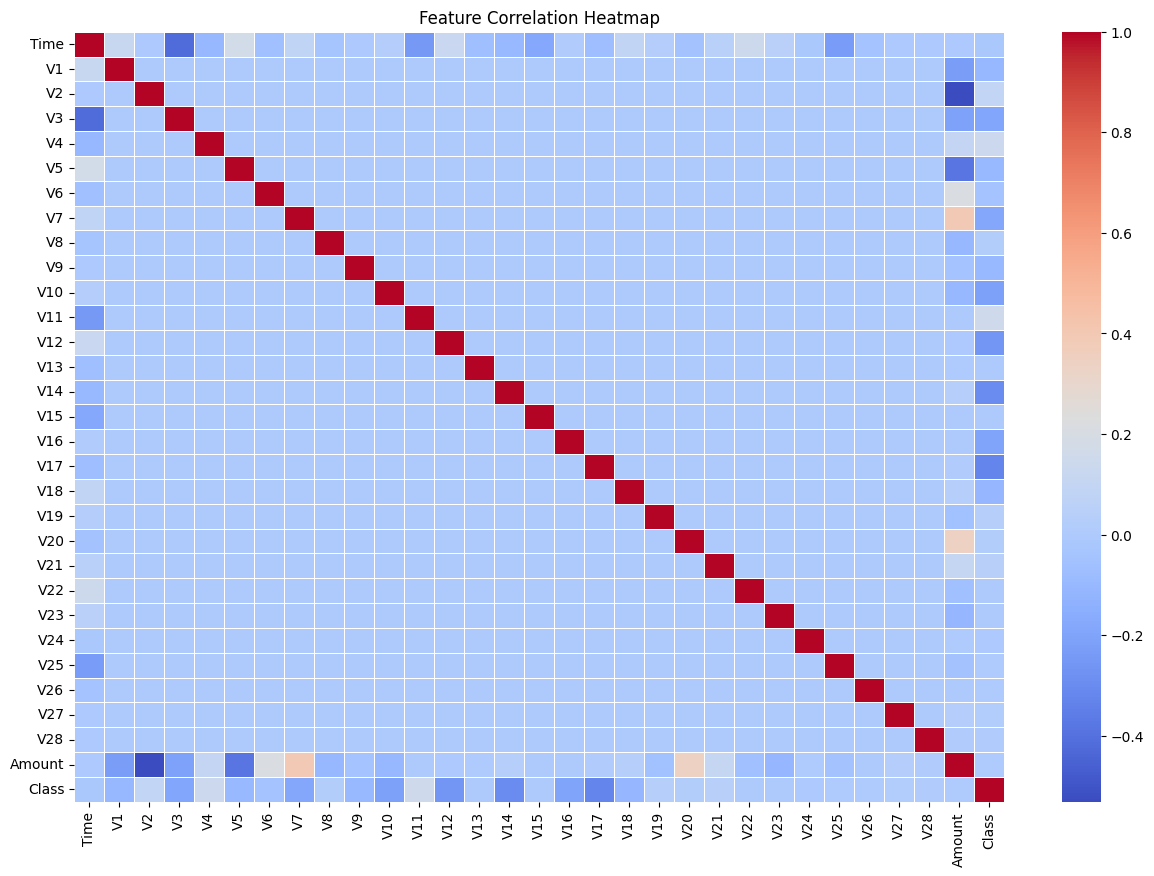

In [34]:
plt.figure(figsize=(15,10))

sns.heatmap(df.corr(), cmap='coolwarm', linewidths=0.5)

plt.title("Feature Correlation Heatmap")
plt.show()



In [35]:
X = df.drop("Class", axis=1)
y = df["Class"]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


In [36]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.06527521 0.05612313]


In [37]:
pca_df = pd.DataFrame(data=X_pca, columns=['PC1','PC2'])

pca_df['Class'] = y.values

pca_df.head()

,PC1,PC2,Class
0,0.416630,-2.532664,0
1,-0.393453,-2.077326,0
2,1.868525,-2.533497,0
3,0.315744,-1.783506,0
4,-0.004379,-1.488415,0


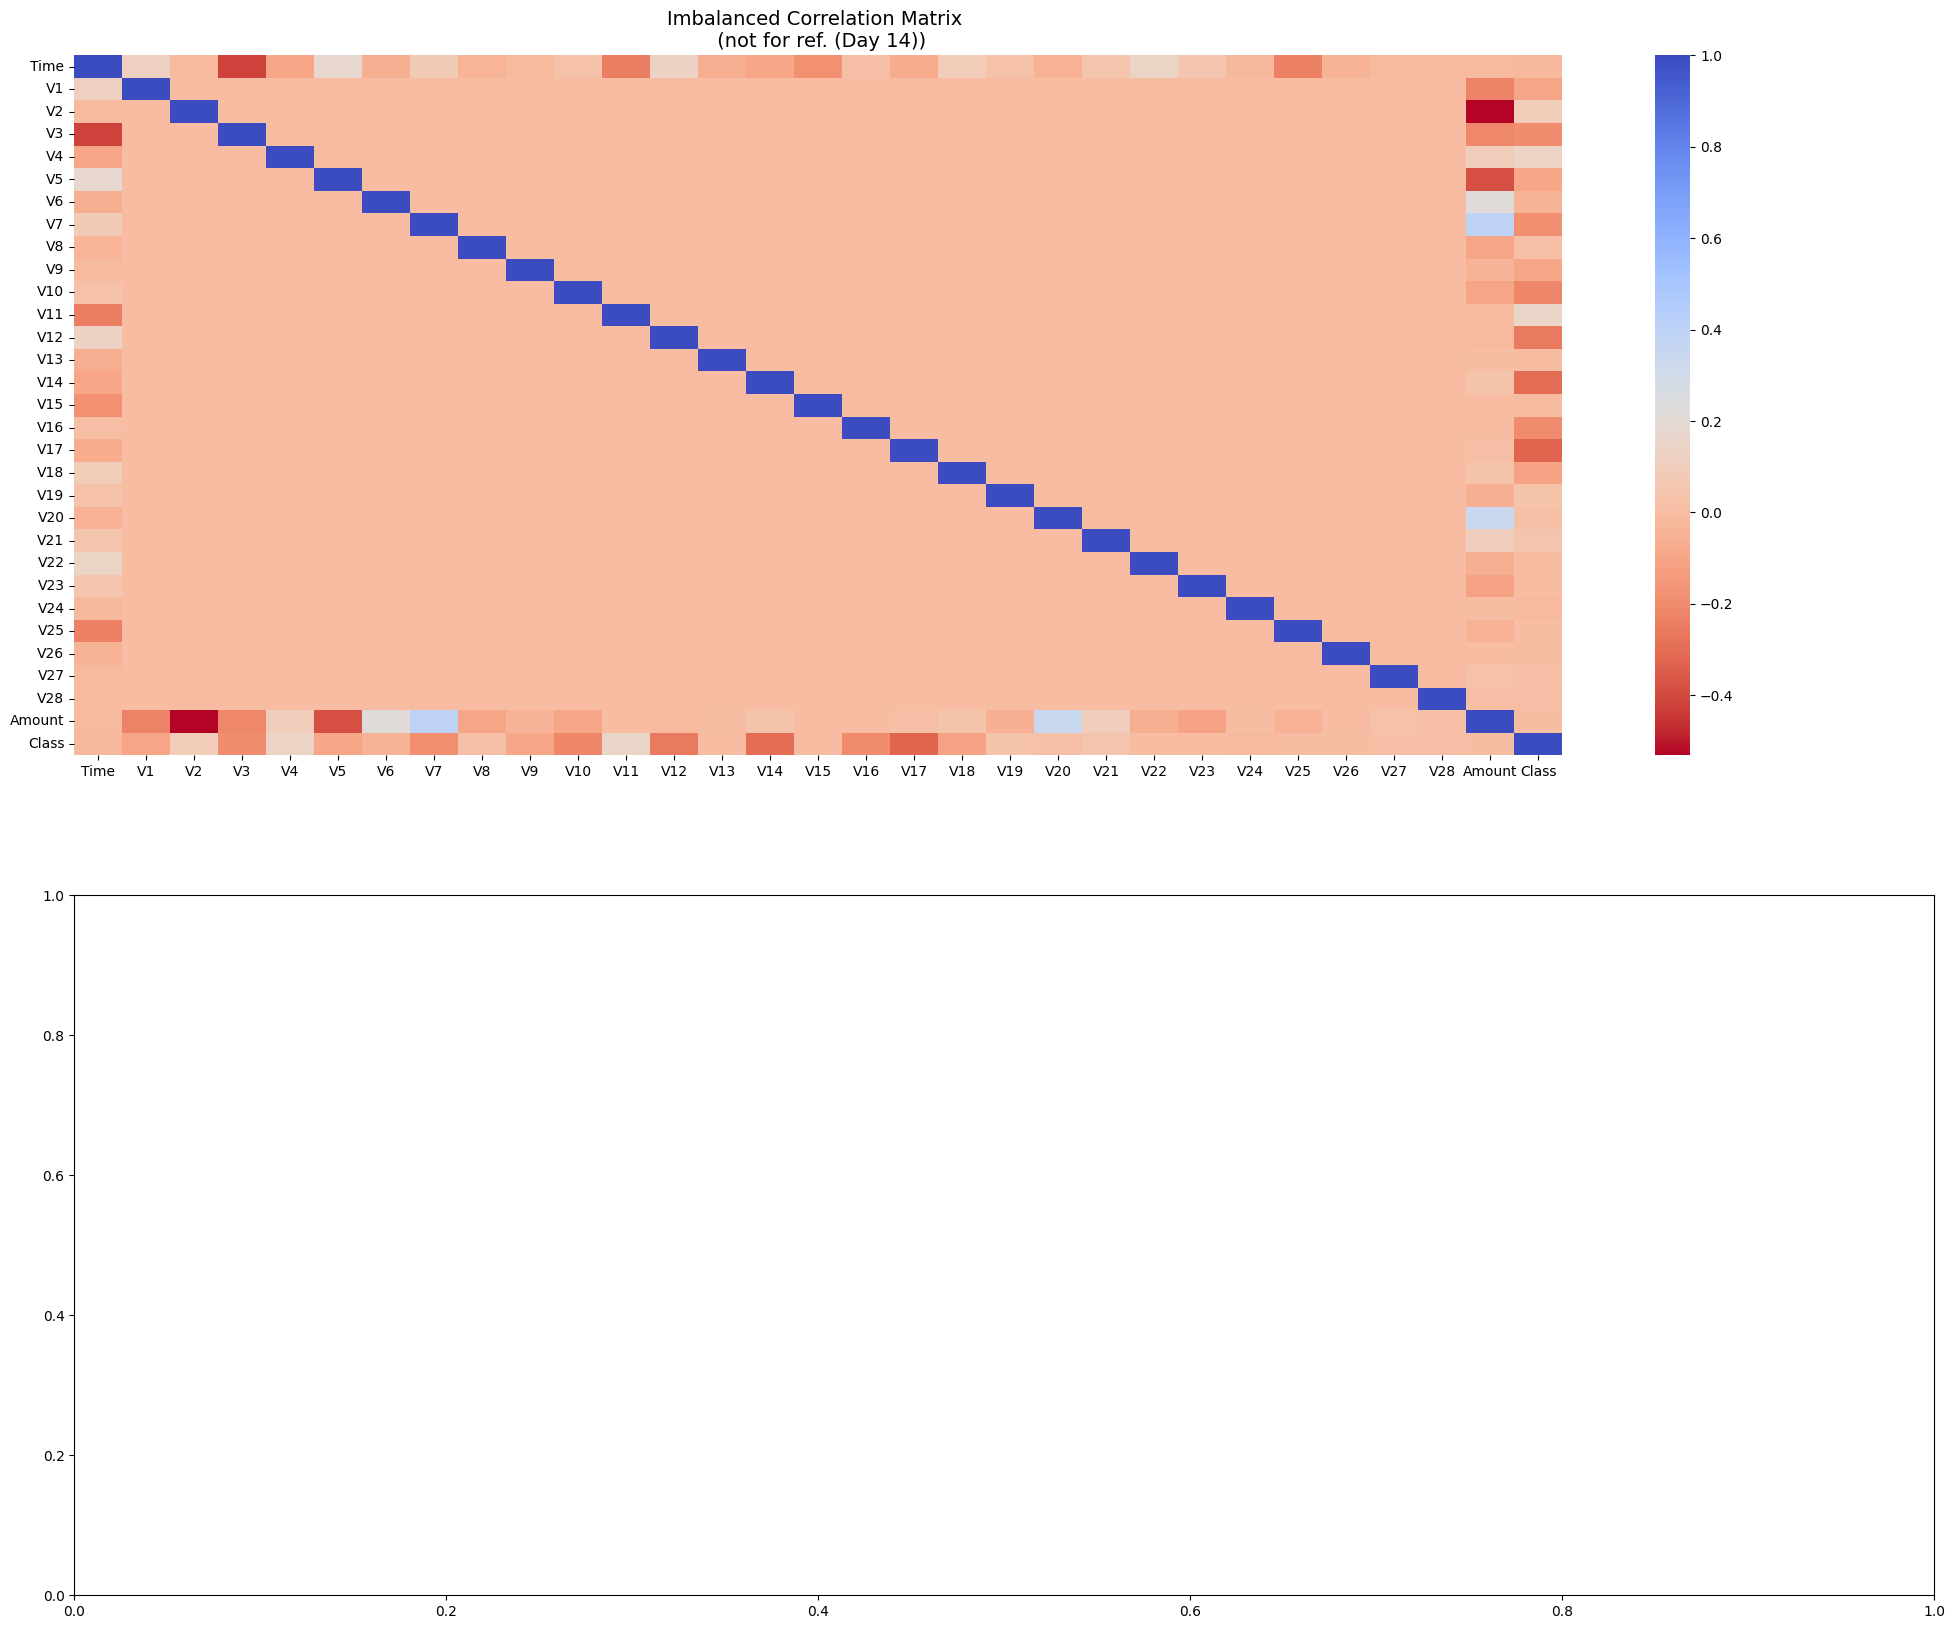

In [42]:

f, (ax1, ax2) = plt.subplots(2, 1, figsize=(24,20))

corr = df.corr()
sns.heatmap(corr, cmap='coolwarm_r', annot_kws={'size':20}, ax=ax1)
ax1.set_title("Imbalanced Correlation Matrix \n (not for ref. (Day 14))", fontsize=14)
plt.show()

In [ ]:
pca_df = pd.DataFrame(data=X_pca, columns=['PC1','PC2'])

pca_df['Class'] = y.values

pca_df.head()

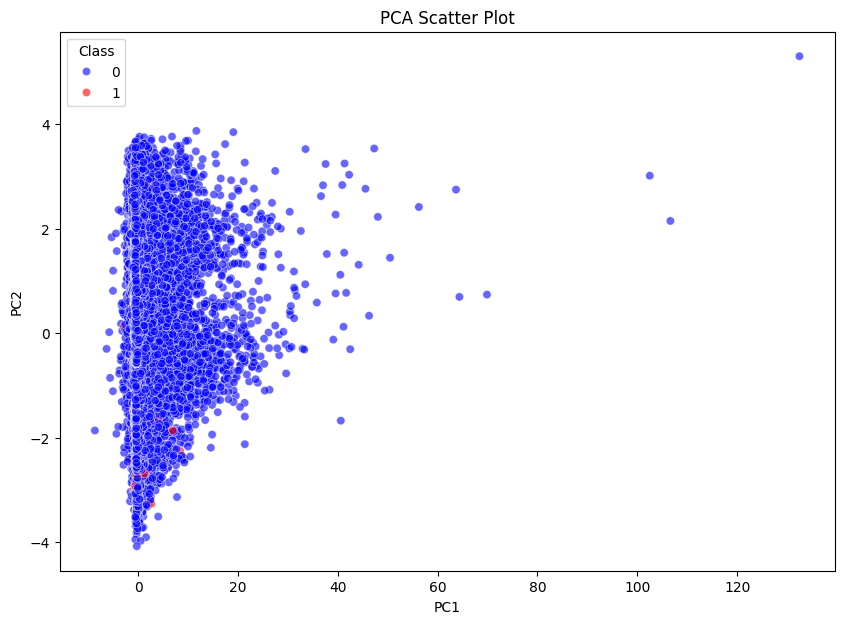

In [39]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Class',
    data=pca_df,
    palette=['blue','red'],
    alpha=0.6
)

plt.title("PCA Scatter Plot")
plt.show()

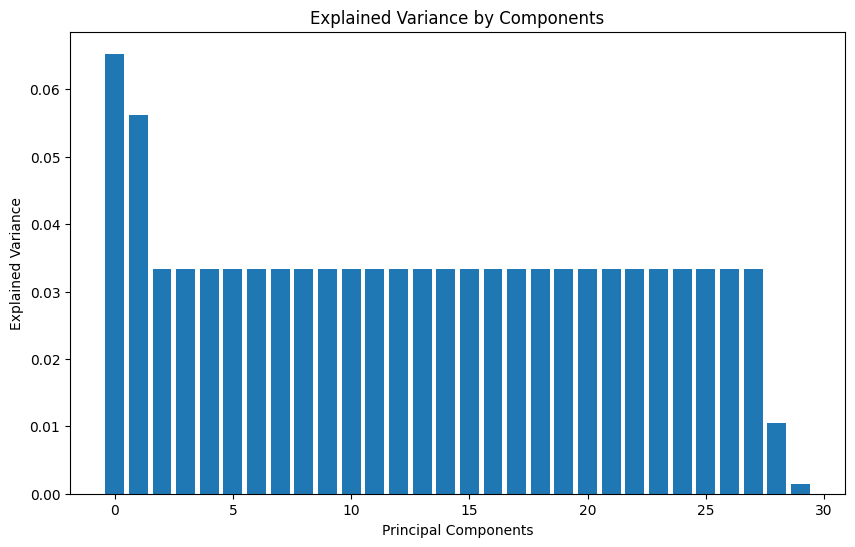

In [43]:
pca_full = PCA()

pca_full.fit(X_scaled)

variance = pca_full.explained_variance_ratio_

plt.figure(figsize=(10,6))

plt.bar(range(len(variance)), variance)

plt.xlabel("Principal Components")
plt.ylabel("Explained Variance")
plt.title("Explained Variance by Components")

plt.show()


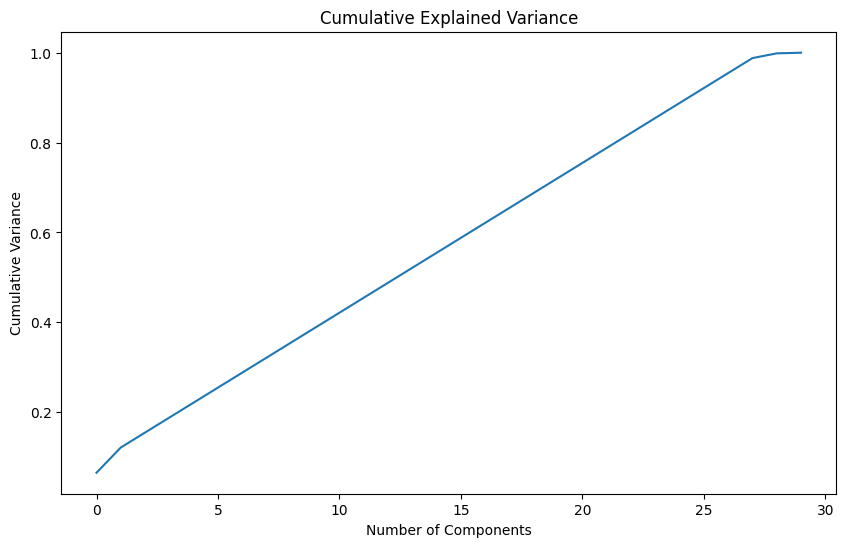

In [44]:
plt.figure(figsize=(10,6))

plt.plot(np.cumsum(variance))

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")

plt.title("Cumulative Explained Variance")

plt.show()

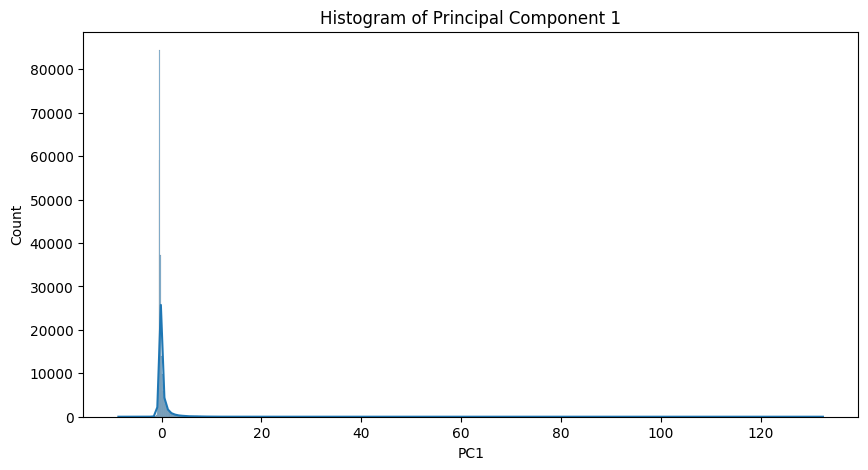

In [45]:
plt.figure(figsize=(10,5))

sns.histplot(pca_df['PC1'], kde=True)

plt.title("Histogram of Principal Component 1")

plt.show()



In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)

model = LogisticRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [47]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.00      0.00      0.00        98

    accuracy                           1.00     56962
   macro avg       0.50      0.50      0.50     56962
weighted avg       1.00      1.00      1.00     56962



C:\Users\Parth\PycharmProjects\PythonProject3\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Parth\PycharmProjects\PythonProject3\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Parth\PycharmProjects\PythonProject3\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

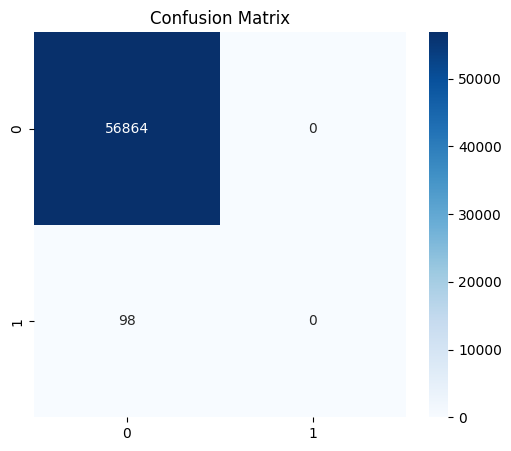

In [48]:
plt.figure(figsize=(6,5))

sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix")

plt.show()



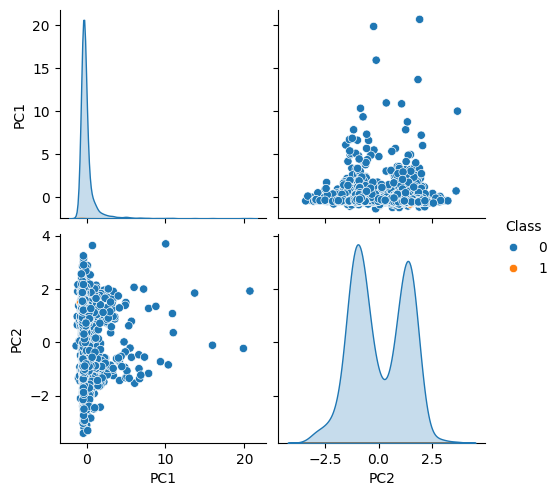

In [49]:
sns.pairplot(
    pca_df.sample(2000),
    hue="Class",
    vars=["PC1","PC2"]
)

plt.show()

In [50]:
pca = PCA(0.95)

X_pca = pca.fit_transform(X_scaled)

print("Number of components selected:", pca.n_components_)

Number of components selected: 27


In [51]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [52]:
pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)

Explained variance ratio: [0.06527521 0.05612313 0.03333333]


In [53]:
pca_df = pd.DataFrame(X_pca, columns=["PC1","PC2","PC3"])
pca_df["Class"] = y.values

pca_df.head()

,PC1,PC2,PC3,Class
0,0.416630,-2.532664,0.596509,0
1,-0.393453,-2.077326,0.601905,0
2,1.868525,-2.533497,-0.059028,0
3,0.315744,-1.783506,-0.156719,0
4,-0.004379,-1.488415,-0.456687,0


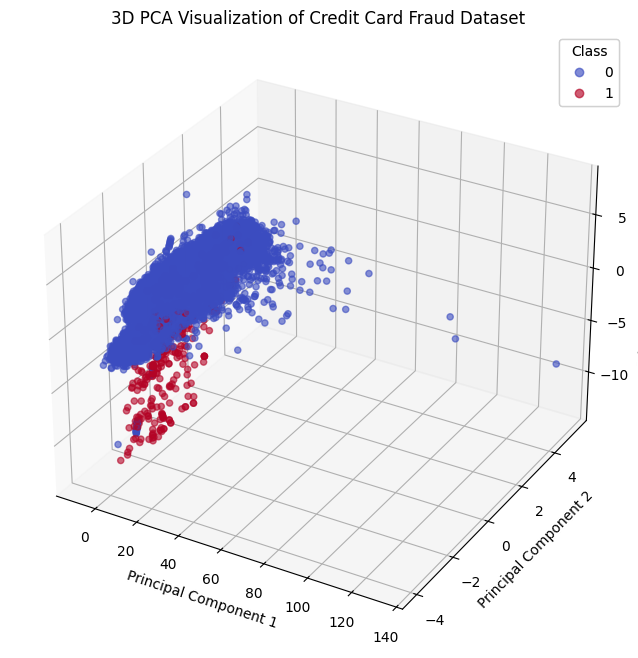

In [54]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    pca_df["PC3"],
    c=pca_df["Class"],
    cmap="coolwarm",
    alpha=0.6
)

ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")

plt.title("3D PCA Visualization of Credit Card Fraud Dataset")

legend1 = ax.legend(*scatter.legend_elements(), title="Class")
ax.add_artist(legend1)

plt.show()

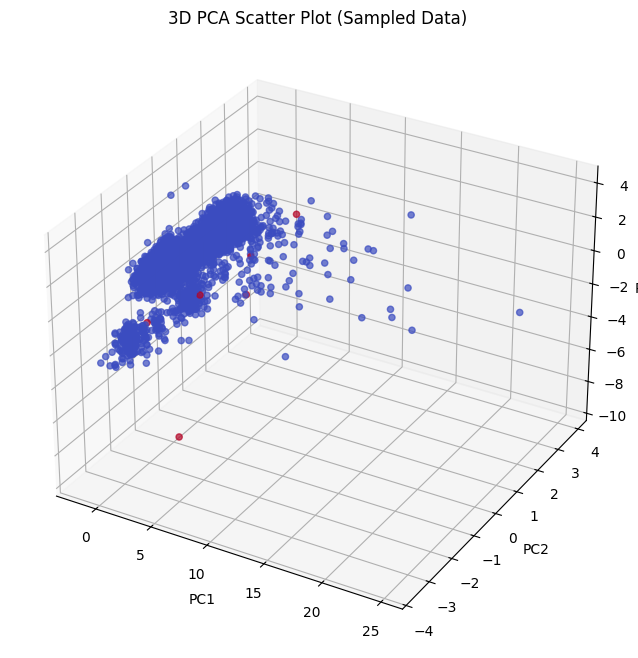

In [55]:
sample = pca_df.sample(5000, random_state=42)

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    sample["PC1"],
    sample["PC2"],
    sample["PC3"],
    c=sample["Class"],
    cmap="coolwarm",
    alpha=0.7
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

plt.title("3D PCA Scatter Plot (Sampled Data)")

plt.show()

In [57]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [59]:
pca_df = pd.DataFrame(X_pca, columns=["PC1","PC2"])
pca_df["Class"] = y.values

In [60]:
loadings = pca.components_.T

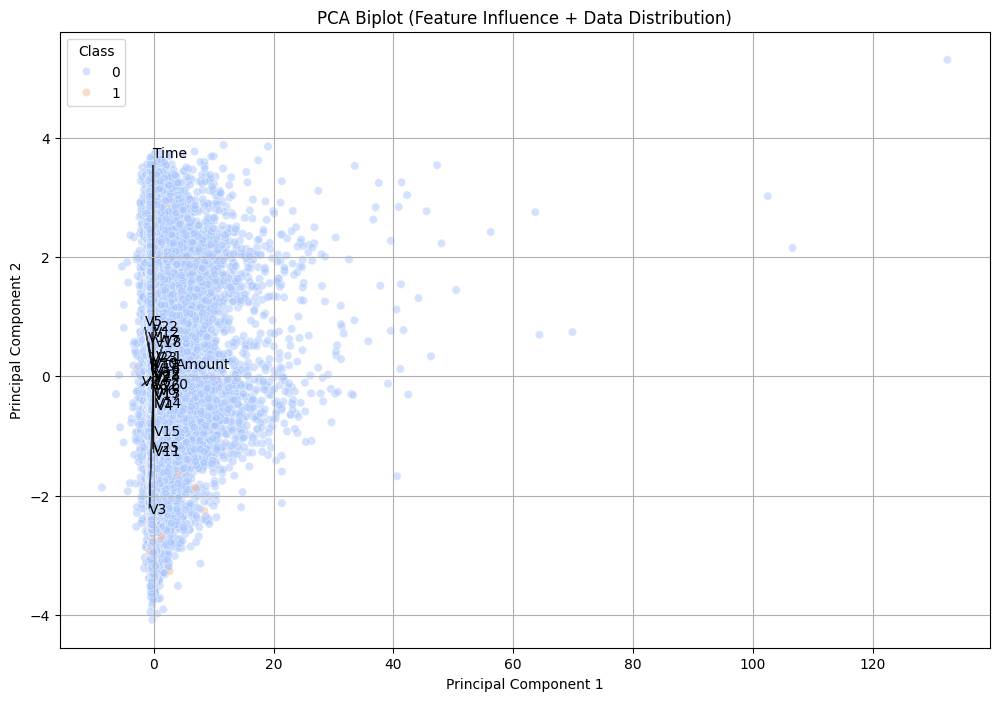

In [61]:
plt.figure(figsize=(12,8))

# scatter plot of PCA components
sns.scatterplot(
    x=pca_df["PC1"],
    y=pca_df["PC2"],
    hue=pca_df["Class"],
    palette="coolwarm",
    alpha=0.5
)

# plot feature vectors
for i, feature in enumerate(X.columns):
    
    plt.arrow(
        0, 0,
        loadings[i,0]*5,
        loadings[i,1]*5,
        color='black',
        alpha=0.7
    )
    
    plt.text(
        loadings[i,0]*5.2,
        loadings[i,1]*5.2,
        feature,
        color='black'
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("PCA Biplot (Feature Influence + Data Distribution)")

plt.grid()
plt.show()

In [67]:
!pip install matplotlib seaborn scikit-learn plotly pandas numpy


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [72]:
sample_df = pca_df.sample(5000, random_state=42)

In [73]:
import plotly.express as px

In [76]:
pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)

Explained variance ratio: [0.06527521 0.05612313 0.03333333]


In [77]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1","PC2","PC3"]
)

pca_df["Class"] = y.values

In [79]:
sample_df = pca_df.sample(5000, random_state=42)

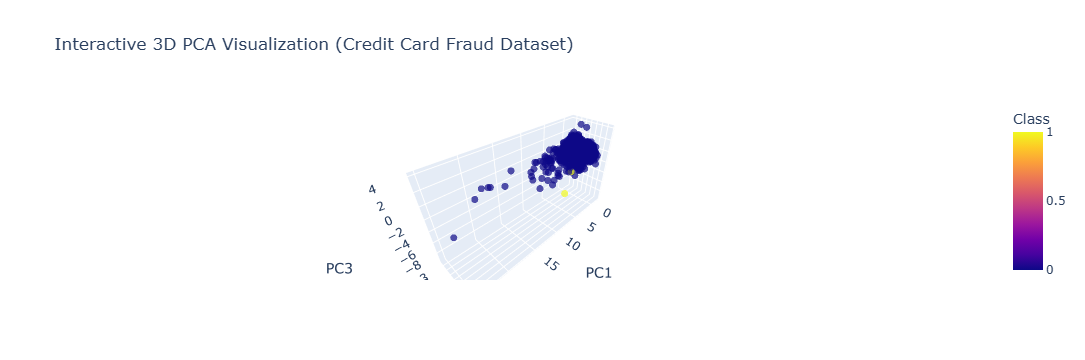

In [80]:
fig = px.scatter_3d(
    sample_df,
    x="PC1",
    y="PC2",
    z="PC3",
    color="Class",
    opacity=0.7,
    title="Interactive 3D PCA Visualization (Credit Card Fraud Dataset)"
)

fig.update_traces(marker=dict(size=4))

fig.show()